<a href="https://colab.research.google.com/github/p-tech/BDAI-Files/blob/main/log_files/log_file_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Real-World Web Log Analysis
In this session, we will analyze traffic from www.almos.org.uk. This log contains a mix of real users, search engine crawlers, and automated system scripts.

Load LogFile

In [ ]:
from google.colab import files
import pandas as pd
import io

# This will prompt the student to select the file from their computer
uploaded = files.upload()

# Get the filename (assuming only one file is uploaded)
filename = list(uploaded.keys())
print(f"Successfully uploaded: {filename}")

Import log file into Pandas

### Parsing the Logs
We are using a Regular Expression (Regex) to extract 10 specific pieces of information from each line:
1. **Domain** (e.g., www.almos.org.uk)
2. **IP** (Supporting both IPv4 and IPv6)
3. **Identity/Auth** (Usually `-`)
4. **Timestamp** (Inside the `[]`)
5. **Request** (The method and URL)
6. **Status** (The HTTP response code)
7. **Size** (Bytes sent)
8. **Referer** (Where the user came from)
9. **User Agent** (The browser or bot name)

In [1]:
import pandas as pd
import re

# This pattern matches your specific log format exactly
log_pattern = r'^(?P<domain>\S+)\s(?P<ip>\S+)\s(?P<ident>\S+)\s(?P<auth>\S+)\s\[(?P<timestamp>.*?)\]\s"(?P<request>.*?)"\s(?P<status>\d+)\s(?P<size>\S+)\s"(?P<referer>.*?)"\s"(?P<user_agent>.*?)"'

# Replace 'your_uploaded_file.log' with the actual name of your file
file_path = 'access_log'

data = []
with open(file_path, 'r') as f:
    for line in f:
        match = re.search(log_pattern, line)
        if match:
            data.append(match.groupdict())

# Create the DataFrame
df = pd.DataFrame(data)

print(f"Successfully loaded {len(df)} lines into the DataFrame.")
df.head()

Successfully loaded 6973 lines into the DataFrame.


,domain,ip,ident,auth,timestamp,request,status,size,referer,user_agent
0,www.slottrackscenics.co.uk,171.6.162.148,-,-,06/Aug/2022:12:14:08 +0100,GET /astros-barcelona-2/ HTTP/1.1,200,10509640,https://www.slottrackscenics.co.uk/,Mozilla/5.0 (Macintosh; Intel Mac OS X 12_5) A...
1,www.slottrackscenics.co.uk,45.8.227.175,-,-,06/Aug/2022:13:37:38 +0100,POST /wp-cron.php?doing_wp_cron=1659789458.700...,200,-,https://www.slottrackscenics.co.uk/wp-cron.php...,WordPress/5.8.1; https://www.slottrackscenics....
2,www.slottrackscenics.co.uk,31.184.236.11,-,-,07/Aug/2022:13:30:18 +0100,GET /product-category/adverts/ HTTP/1.1,200,120688,https://www.slottrackscenics.co.uk/product-cat...,Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.3...
3,www.slottrackscenics.co.uk,127.0.0.1,-,-,07/Aug/2022:13:30:19 +0100,GET /wp-content/uploads/2020/09/AB1-A-contents...,200,12578,https://www.slottrackscenics.co.uk/product-cat...,Serf/1.3.9 (mod_pagespeed/1.13.35.2-0)
4,www.slottrackscenics.co.uk,127.0.0.1,-,-,07/Aug/2022:13:30:20 +0100,GET /wp-content/uploads/2022/03/AB1RP-200x160....,200,8263,https://www.slottrackscenics.co.uk/product-cat...,Serf/1.3.9 (mod_pagespeed/1.13.35.2-0)


Look at the output. We have mixed IPv4 and IPv6 addresses, status codes like 429 (Too Many Requests), and clear "User-Agent" strings identifying bots (Facebook, Google, and WordPress).

**Step 1:** Identifying Bot Traffic
In this log, the Facebook crawler (meta-externalagent) is being Rate Limited.

Status Code 429: Means "Too Many Requests." The server is telling the bot to slow down.

**Step 2:** Spotting WordPress Automation
Look for wp-cron.php. This is an internal WordPress task manager, not a real user.

**Cleaning the Data Types**
By default, everything we just pulled is a "string" (text). To do math or sort by date, we need to convert them to numbers and real timestamps.

In [2]:
# 1. Convert Status to integers (for numerical analysis)
df['status'] = df['status'].astype(int)

# 2. Convert Size to numbers (some lines have '-' which we turn into 0)
df['size'] = pd.to_numeric(df['size'], errors='coerce').fillna(0).astype(int)

# 3. Convert Timestamp to a real Python datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%b/%Y:%H:%M:%S %z')

print("Data types converted successfully!")
df.info()

Data types converted successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6973 entries, 0 to 6972
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype                    
---  ------      --------------  -----                    
 0   domain      6973 non-null   object                   
 1   ip          6973 non-null   object                   
 2   ident       6973 non-null   object                   
 3   auth        6973 non-null   object                   
 4   timestamp   6973 non-null   datetime64[ns, UTC+01:00]
 5   request     6973 non-null   object                   
 6   status      6973 non-null   int64                    
 7   size        6973 non-null   int64                    
 8   referer     6973 non-null   object                   
 9   user_agent  6973 non-null   object                   
dtypes: datetime64[ns, UTC+01:00](1), int64(2), object(7)
memory usage: 544.9+ KB


# Code Exploration

In [3]:
print("--- 1. Breakdown of HTTP Status Codes ---")
# Students should see 429, 200, 301, and 302 here
print(df['status'].value_counts())

print("\n--- 2. Top User Agents (Who is visiting?) ---")
# This helps identify Googlebot, Facebook, and WordPress
print(df['user_agent'].value_counts())

# Filter for 429s
rate_limited = df[df['status'] == 429]

if rate_limited.empty:
    print("❌ No 429 errors found. Check if the Regex captured the 'status' column correctly.")
    print("Current column names:", df.columns.tolist())
else:
    print(f"✅ Found {len(rate_limited)} rate-limited requests.")
    # Use .head() to avoid flooding the screen
    print(rate_limited[['ip', 'status', 'request']].head(10))

--- 1. Breakdown of HTTP Status Codes ---
status
200    6551
404     184
301     163
302      62
403       7
409       6
Name: count, dtype: int64

--- 2. Top User Agents (Who is visiting?) ---
user_agent
Serf/1.3.9 (mod_pagespeed/1.13.35.2-0)                                                                                                                                   5276
WordPress/5.8.1; https://www.slottrackscenics.co.uk                                                                                                                       359
Mozilla/5.0 (iPhone; CPU iPhone OS 15_6 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/15.6 Mobile/15E148 Safari/604.1                                    88
Mozilla/5.0 (Windows NT 10.0; Win64; x64; Xbox; Xbox One) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/103.0.0.0 Safari/537.36 Edge/44.18363.8131                         55
Mozilla/5.0 (iPad; CPU OS 15_6 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/15.6

In [4]:
# Force conversion to numeric, turning errors into NaN
df['status'] = pd.to_numeric(df['status'], errors='coerce')

# Filter for 429s
rate_limited = df[df['status'] == 429]

if rate_limited.empty:
    print("❌ No 429 errors found. Check if the Regex captured the 'status' column correctly.")
    print("Current column names:", df.columns.tolist())
else:
    print(f"✅ Found {len(rate_limited)} rate-limited requests.")
    # Use .head() to avoid flooding the screen
    print(rate_limited[['ip', 'status', 'request']].head(10))

❌ No 429 errors found. Check if the Regex captured the 'status' column correctly.
Current column names: ['domain', 'ip', 'ident', 'auth', 'timestamp', 'request', 'status', 'size', 'referer', 'user_agent']


# Identifying and Categorizing Bots
In this cell, we will create a new column called is_bot and then filter for the most common ones.

In [5]:
# Define common bot keywords
bot_keywords = 'bot|crawler|spider|slurp|externalagent|wordpress|serf'

# Create a boolean column for bots (case-insensitive)
df['is_bot'] = df['user_agent'].str.contains(bot_keywords, case=False, na=False)

# Create a separate DataFrame for just the bots
bots_df = df[df['is_bot'] == True].copy()

print(f"Detected {len(bots_df)} bot-related requests out of {len(df)} total lines.")

Detected 5788 bot-related requests out of 6973 total lines.


# Listing the "Main" Bots
To make this readable for students, we should group the bots by their User-Agent and count them.

In [6]:
print("--- Top 10 Bots by Request Volume ---")
# We count how many times each unique User-Agent appears
top_bots = bots_df['user_agent'].value_counts().head(10)

# Display as a clean table
print(top_bots.to_frame(name='Request Count'))

# Optional: Find the most active Bot IP
print("\n--- Most Active Bot IP Addresses ---")
print(bots_df['ip'].value_counts().head(5))

--- Top 10 Bots by Request Volume ---
                                                    Request Count
user_agent                                                       
Serf/1.3.9 (mod_pagespeed/1.13.35.2-0)                       5276
WordPress/5.8.1; https://www.slottrackscenics.c...            359
Mozilla/5.0 (compatible; bingbot/2.0; +http://w...             48
Mozilla/5.0 (compatible; AhrefsBot/7.0; +http:/...             19
Mozilla/5.0 (compatible; SemrushBot-BA; +http:/...             17
Mozilla/5.0 (compatible; Googlebot/2.1; +http:/...             15
Mozilla/5.0 (compatible; SemrushBot/7~bl; +http...             11
Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bui...             10
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_5)...              8
Googlebot-Image/1.0                                             5

--- Most Active Bot IP Addresses ---
ip
127.0.0.1        5276
45.8.227.175      359
157.55.39.175      12
66.249.66.52       11
157.55.39.66       10
Name: count, dtype:

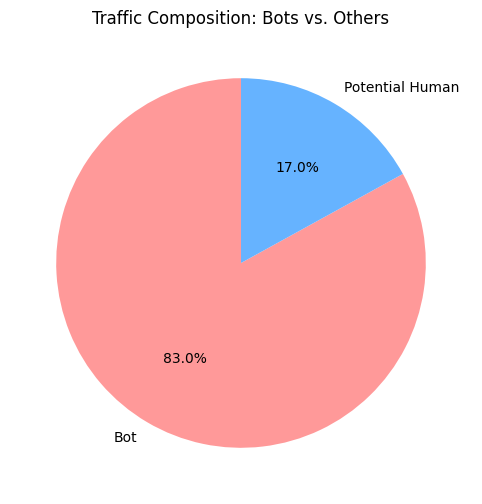

In [7]:
import matplotlib.pyplot as plt

# Count Bot vs Human
traffic_type = df['is_bot'].value_counts()
traffic_type.index = ['Bot', 'Potential Human'] # Rename for the chart

# Plot
plt.figure(figsize=(8, 6))
traffic_type.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Traffic Composition: Bots vs. Others')
plt.ylabel('') # Remove the default 'is_bot' label
plt.show()

# Exporting Bot Data for Further Investigation
This step is useful for sharing findings with a security team or keeping a record of specific bot behaviors.

In [8]:
# 1. Filter for bots AND exclude the localhost IP (127.0.0.1)
# We use the != operator to "keep everything that is NOT 127.0.0.1"
external_bots_df = df[(df['is_bot'] == True) & (df['ip'] != '127.0.0.1')].copy()

# 2. Sort by IP address and then by Timestamp
bots_sorted = external_bots_df.sort_values(by=['ip', 'timestamp'])

# 3. Export to CSV
output_filename = 'filtered_bots_analysis.csv'
bots_sorted.to_csv(output_filename, index=False)

print(f"Total lines in original data: {len(df)}")
print(f"Lines excluded (Localhost): {len(df[df['ip'] == '127.0.0.1'])}")
print(f"Final bot records exported: {len(bots_sorted)}")

# Trigger the download in Colab
from google.colab import files
files.download(output_filename)

Total lines in original data: 6973
Lines excluded (Localhost): 5276
Final bot records exported: 512


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Visualizing Traffic Volume with a Treemap**
This visualization helps students immediately see the "Heavy Hitters"—IPs that might be scraping large amounts of data.

In [9]:
import plotly.express as px

# 1. Prepare data: Filter for bots, exclude localhost
bots_only = df[(df['is_bot'] == True) & (df['ip'] != '127.0.0.1')].copy()

# 2. Group by both IP and User-Agent to see the breakdown
bot_summary = bots_only.groupby(['ip', 'user_agent']).agg(
    access_count=('ip', 'count'),
    total_bytes=('size', 'sum')
).reset_index()

# 3. Draw the Treemap
# 'path' defines the hierarchy: IP -> User Agent
fig = px.treemap(
    bot_summary,
    path=[px.Constant("All Bots"), 'ip', 'user_agent'],
    values='access_count',
    color='total_bytes',
    color_continuous_scale='RdBu',
    title='Bot Fingerprinting: IP Address & User-Agent Breakdown',
    hover_data=['total_bytes']
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Shared Identities: They might see one IP box contain multiple smaller boxes (User-Agents). This often indicates a proxy or a single server running multiple different crawling scripts.

Volume vs. Identity: A bot might have a very "loud" identity (many hits) but very "light" data footprint (darker/different color).

Bot Fingerprinting: If students see the same User-Agent appearing under ten different IP addresses, they’ve just identified a distributed botnet or a large-scale crawler like Facebook's meta-externalagent.

# Mapping the Bot's Path
We will create a function that allows a student to input an IP address and get a "Click Stream" of that bot's activity.

In [11]:
# Choose a specific IP from your Treemap (e.g., the Facebook crawler)
target_ip = '45.8.227.175'

# Filter for just this IP
bot_activity = df[df['ip'] == target_ip].copy()

# Group by the 'request' column to see which URLs were targeted
url_counts = bot_activity['request'].value_counts().reset_index()
url_counts.columns = ['URL Requested', 'Hit Count']

print(f"--- Activity Report for IP: {target_ip} ---")
print(f"Total Requests: {len(bot_activity)}")
print(f"Unique URLs Accessed: {len(url_counts)}")
print("\nTop Requested URLs:")
print(url_counts.head(30))

--- Activity Report for IP: 45.8.227.175 ---
Total Requests: 359
Unique URLs Accessed: 357

Top Requested URLs:
                                        URL Requested  Hit Count
0                                      GET / HTTP/1.1          3
1   POST /wp-cron.php?doing_wp_cron=1659927704.862...          1
2   POST /wp-cron.php?doing_wp_cron=1659927614.418...          1
3   POST /wp-cron.php?doing_wp_cron=1659833885.436...          1
4   POST /wp-cron.php?doing_wp_cron=1659833340.234...          1
5   POST /wp-cron.php?doing_wp_cron=1659833337.685...          1
6   POST /wp-cron.php?doing_wp_cron=1659926706.852...          1
7   POST /wp-cron.php?doing_wp_cron=1659832291.128...          1
8   POST /wp-cron.php?doing_wp_cron=1659832112.223...          1
9   POST /wp-cron.php?doing_wp_cron=1659831702.200...          1
10  POST /wp-cron.php?doing_wp_cron=1659831569.404...          1
11  POST /wp-cron.php?doing_wp_cron=1659924787.808...          1
12  POST /wp-cron.php?doing_wp_cron=1659924

Identifying Intent
Have the students analyze the URL list for their chosen IP:

The "Good" Bot: Does it mostly access public articles and CSS files? (e.g., Googlebot indexing content).

The "Aggressive" Bot: Does it have a high number of 429 status codes? (This means the server is actively blocking it for being too fast).

The "System" Bot: Does it only hit wp-cron.php? (This is your internal WordPress system keeping the site running).

In [12]:
import plotly.express as px

# Create a scatter plot of requests over time for this specific bot
fig = px.scatter(
    bot_activity,
    x='timestamp',
    y='request',
    color='status',
    title=f'Timeline of Requests from {target_ip}',
    labels={'timestamp': 'Time of Day', 'request': 'URL Path'},
    hover_data=['status', 'size']
)

fig.update_layout(height=600)
fig.show()

The "Wall of Shame" (Suspicious Bot Detection)We will rank bots based on their Error Ratio. If an IP has a high percentage of $403$ (Forbidden), $404$ (Not Found), or $429$ (Rate Limited) responses, it is likely a malicious scanner or an aggressive scraper.

We will now calculate a **Suspicion Score**.
* **High Hits + High Errors ($4xx$):** This usually indicates a "Scraper" or "Vulnerability Scanner."
* **Targeting Admin Paths:** Any IP hitting `/wp-admin` or `.env` files is flagged immediately.



In [13]:
# 1. Define the 'Threat Dictionary'
status_labels = {
    401: "Unauthorized (Login Probe)",
    403: "Forbidden (Access Denied)",
    404: "Not Found (Directory Scanning)",
    405: "Method Not Allowed (Exploit Attempt)",
    429: "Rate Limited (Aggressive Scraper)"
}

# 2. Add a 'threat_type' column to the main DataFrame
df['threat_type'] = df['status'].map(status_labels).fillna("Normal / Other")

# 3. Create a summary of threats per IP
threat_summary = df[df['status'].isin(status_labels.keys())].groupby(['ip', 'threat_type']).size().reset_index(name='incident_count')

# 4. Sort to see the most active "Threats"
threat_summary = threat_summary.sort_values(by='incident_count', ascending=False)

print("--- Categorized Security Incidents ---")
display(threat_summary.head(25))

--- Categorized Security Incidents ---


,ip,threat_type,incident_count
2,127.0.0.1,Not Found (Directory Scanning),96
30,45.129.96.149,Not Found (Directory Scanning),11
35,46.175.147.154,Not Found (Directory Scanning),10
36,5.154.181.79,Not Found (Directory Scanning),8
31,45.129.96.154,Not Found (Directory Scanning),7
3,152.89.196.102,Forbidden (Access Denied),5
42,87.107.68.173,Not Found (Directory Scanning),4
34,46.175.144.212,Not Found (Directory Scanning),3
44,91.151.93.12,Not Found (Directory Scanning),3
29,31.223.49.66,Not Found (Directory Scanning),2


In your specific log file, you have several 429 and 301/302 codes. Adding this section helps students distinguish between a "Bot doing its job" and a "Bot being bad."

404 (Not Found): If an IP hits 50 different 404s in 1 minute, they are "Fuzzing"—guessing URL names to find a forgotten backup or a hidden login page.

405 (Method Not Allowed): This often happens if a hacker tries to POST data (like a password) to a page that only allows GET (viewing). It's a huge red flag.

401 (Unauthorized): In a WordPress context, this usually means someone tried to access /wp-admin without a session cookie or with a failed login attempt.

In [14]:
import plotly.express as px

# Only plot IPs that triggered at least one of our defined security codes
fig = px.bar(
    threat_summary,
    x='ip',
    y='incident_count',
    color='threat_type',
    title='Security Incident Breakdown by IP Address',
    labels={'incident_count': 'Number of Errors', 'ip': 'Attacker IP'},
    barmode='stack'
)

fig.show()

# Analyzing Real Human Traffic
Now we are filtering the data to see only what **real people** (non-bots) are reading.
We will exclude:
* **Bots** (as identified by User-Agent)
* **Assets** (Images, CSS, JavaScript, Fonts)
* **Internal System Calls** (Localhost 127.0.0.1)

In [15]:
# 1. Define the "Noise" extensions to exclude
noise_extensions = r'\.jpg|\.jpeg|\.png|\.gif|\.css|\.js|\.woff|\.svg|\.ico'

# 2. Apply the filters
# - Must NOT be a bot
# - Must NOT be 127.0.0.1
# - Must NOT contain noise extensions in the request URL
human_traffic = df[
    (df['is_bot'] == False) &
    (df['ip'] != '127.0.0.1') &
    (~df['request'].str.contains(noise_extensions, case=False, na=False))
].copy()

# 3. Clean up the 'request' string to just show the URL (remove 'GET ' and ' HTTP/1.1')
human_traffic['clean_url'] = human_traffic['request'].str.replace(r'^GET |^POST | HTTP/1.1$', '', regex=True)

print(f"Total Log Entries: {len(df)}")
print(f"Actual Content Pages viewed by humans: {len(human_traffic)}")

# Display the top 10 most popular pages
print("\n--- Most Popular Content Pages (Human Only) ---")
top_pages = human_traffic['clean_url'].value_counts().head(10)
display(top_pages.to_frame(name='Views'))

Total Log Entries: 6973
Actual Content Pages viewed by humans: 958

--- Most Popular Content Pages (Human Only) ---


,Views
clean_url,
/just-one-week-go/,74
/wp-comments-post.php,56
/home-track-pit-lane-2/pit-lane-version-2b-copy/,48
/contact-us/,44
/after-the-race/ep-2/,33
/astros-barcelona/astro1-2/,28
/astros-barcelona-2/,28
/just-three-weeks-go/,27
/christmas-is-coming/,27


# The "Reading List" Report
This helps students see exactly what the audience is interested in.

In [16]:
# Group by URL and show the Status Codes (to see if humans are hitting errors)
content_report = human_traffic.groupby(['clean_url', 'status']).size().reset_index(name='view_count')
content_report = content_report.sort_values(by='view_count', ascending=False)

# Export this for your records
content_report.to_csv('human_content_views.csv', index=False)

print("Report saved as 'human_content_views.csv'")
display(content_report.head(15))

Report saved as 'human_content_views.csv'


,clean_url,status,view_count
86,/just-one-week-go/,200,74
80,/home-track-pit-lane-2/pit-lane-version-2b-copy/,200,48
241,/wp-comments-post.php,302,46
70,/contact-us/,200,39
45,/after-the-race/ep-2/,200,33
49,/astros-barcelona-2/,200,28
50,/astros-barcelona/astro1-2/,200,28
87,/just-three-weeks-go/,200,27
62,/christmas-is-coming/,200,27
234,/wp-admin/admin-ajax.php,200,24


In [17]:
import plotly.express as px

# Count views per hour/minute
human_traffic.set_index('timestamp', inplace=True)
time_series = human_traffic.resample('1min').size().reset_index(name='page_views')

fig = px.line(time_series, x='timestamp', y='page_views', title='Human Page Views Over Time')
fig.show()

# Reset index for further cells
human_traffic.reset_index(inplace=True)

### 📈 Step 14: Unique Visitor Analysis
In this step, we identify individual "journeys."
We are looking for:
1. **Who?** (Unique IP Address)
2. **When?** (The specific Date of access)
3. **How much?** (Count of unique URLs visited)

In [18]:
# 1. Create a 'Date' only column (ignoring the specific hour/minute)
human_traffic['entry_date'] = human_traffic['timestamp'].dt.date

# 2. Group by IP and Date
# We calculate:
# - total_pages: Total number of clicks
# - unique_pages: Number of different URLs they looked at
visitor_stats = human_traffic.groupby(['ip', 'entry_date']).agg(
    total_clicks=('clean_url', 'count'),
    unique_pages_viewed=('clean_url', 'nunique')
).reset_index()

# 3. Sort by the most active "Human" visitors
visitor_stats = visitor_stats.sort_values(by='unique_pages_viewed', ascending=False)

print(f"Detected {len(visitor_stats)} unique IP/Date sessions.")
display(visitor_stats.head(15))

Detected 520 unique IP/Date sessions.


,ip,entry_date,total_clicks,unique_pages_viewed
341,2a00:23c6:c806:1b01:b12e:cf63:8369:7fd4,2022-08-07,35,14
421,46.175.147.154,2022-08-07,16,13
392,45.129.96.154,2022-08-08,12,11
391,45.129.96.149,2022-08-08,11,10
427,5.154.181.79,2022-08-07,14,10
406,45.23.217.194,2022-08-08,15,9
390,45.129.96.149,2022-08-07,9,8
458,77.232.38.96,2022-08-06,7,7
420,46.175.144.212,2022-08-08,7,7
36,109.107.180.231,2022-08-06,6,6


# Visualizing Visitor Depth
It's helpful for students to see the distribution. Are most people looking at 1 page, or are they browsing 10+ pages?

In [19]:
import plotly.express as px

fig = px.histogram(
    visitor_stats,
    x='unique_pages_viewed',
    nbins=20,
    title='Distribution of Visitor Depth (Pages per Session)',
    labels={'unique_pages_viewed': 'Number of Unique Pages Accessed', 'count': 'Number of Visitors'},
    color_discrete_sequence=['#2ecc71']
)

fig.update_layout(bargap=0.1)
fig.show()

In [20]:
visitor_stats.to_csv('unique_human_visitors.csv', index=False)
print("Visitor Journey Report saved as 'unique_human_visitors.csv'")

Visitor Journey Report saved as 'unique_human_visitors.csv'


# Reverse DNS Lookup
A **Reverse DNS (rDNS)** lookup asks the internet: "What name is registered to this IP address?"
This helps us verify:
* Is a bot truly from Google or Facebook?
* Is a visitor using a known VPN or ISP (like Comcast or British Telecom)?

In [21]:
import socket

def get_domain(ip):
    try:
        # gethostbyaddr returns (hostname, aliaslist, ipaddrlist)
        # We only want the primary hostname
        return socket.gethostbyaddr(ip)
    except (socket.herror, socket.gaierror, Exception):
        # Return 'Unknown' if the lookup fails or takes too long
        return "Unknown / No PTR Record"

# 1. Get unique IPs from our visitor stats to save time
# (No need to lookup the same IP 100 times!)
unique_ips = visitor_stats['ip'].unique()

# 2. Create a lookup dictionary
print(f"Performing reverse lookup for {len(unique_ips)} unique IPs...")
ip_to_domain = {ip: get_domain(ip) for ip in unique_ips}

# 3. Map the domains back to our visitor table
visitor_stats['domain'] = visitor_stats['ip'].map(ip_to_domain)

display(visitor_stats[['ip', 'domain', 'unique_pages_viewed']].head(15))

Performing reverse lookup for 433 unique IPs...


,ip,domain,unique_pages_viewed
341,2a00:23c6:c806:1b01:b12e:cf63:8369:7fd4,Unknown / No PTR Record,14
421,46.175.147.154,Unknown / No PTR Record,13
392,45.129.96.154,"(name4.arlnorth.us.com, [], [45.129.96.154])",11
391,45.129.96.149,"(786381-vds-raka.gmhost.pp.ua, [], [45.129.96....",10
427,5.154.181.79,"(629506-vds-yevhenpetrov6.gmhost.pp.ua, [], [5...",10
406,45.23.217.194,Unknown / No PTR Record,9
390,45.129.96.149,"(786381-vds-raka.gmhost.pp.ua, [], [45.129.96....",8
458,77.232.38.96,"(v981717.macloud.host, [], [77.232.38.96])",7
420,46.175.144.212,Unknown / No PTR Record,7
36,109.107.180.231,"(host-109-107-180-231.macloud.host, [], [109.1...",6


# Identifying "Fakers"
Students can now write a simple check: "If the User-Agent says 'Googlebot' but the Domain does not contain 'googlebot.com', is it a fake?"

In [22]:
# Quick check for suspicious authenticity
# (Assuming you still have the User-Agent data in your main 'df')
verification = df[['ip', 'user_agent']].drop_duplicates()

# Map the resolved domains
verification['resolved_domain'] = verification['ip'].map(ip_to_domain)

# Ensure the 'resolved_domain' column contains only strings (the hostname)
# If the entry is a tuple, extract the first element (hostname); otherwise, use the entry as is.
verification['resolved_domain'] = verification['resolved_domain'].apply(
    lambda x: x[0] if isinstance(x, tuple) else x
)

# Look for 'Google' in Agent but NOT in Domain
fakes = verification[
    (verification['user_agent'].str.contains('Google', case=False, na=False)) &
    (~verification['resolved_domain'].str.contains('google', case=False, na=False))
]

if not fakes.empty:
    print("🚨 Potential FAKE Googlebots detected:")
    display(fakes)
else:
    print("✅ No obvious bot spoofing detected in this sample.")

🚨 Potential FAKE Googlebots detected:


,ip,user_agent,resolved_domain
122,66.249.66.54,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,NaN
196,66.249.66.84,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN
753,66.249.66.152,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,NaN
1270,66.249.66.152,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN
1271,66.249.66.192,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN
1560,66.249.66.156,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN
1565,66.249.66.52,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",NaN
1567,66.249.66.84,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,NaN
2451,66.249.66.222,Mozilla/5.0 (Linux; Android 6.0.1; Nexus 5X Bu...,NaN
2767,66.249.66.8,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...,NaN


# Final Export of Human Visitor Data
We are now exporting our analyzed "Human" traffic. This file contains:
1. **IP Address** 2. **Entry Date**
3. **Domain Name** (via Reverse DNS)
4. **Volume Metrics** (Total clicks vs. Unique pages)

In [23]:
# 1. Ensure the 'domain' column is mapped to our visitor_stats
visitor_stats['domain'] = visitor_stats['ip'].map(ip_to_domain)

# 2. Final Sorting (Most active visitors first)
final_export_df = visitor_stats.sort_values(by=['unique_pages_viewed', 'entry_date'], ascending=False)

# 3. Define the filename
csv_filename = 'human_visitor_audit_2025.csv'

# 4. Save to the Colab environment
final_export_df.to_csv(csv_filename, index=False)

print(f"✅ Success! Generated {csv_filename} with {len(final_export_df)} unique sessions.")

# 5. Trigger the browser download
from google.colab import files
files.download(csv_filename)

✅ Success! Generated human_visitor_audit_2025.csv with 520 unique sessions.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Human Traffic Audit
This table identifies our most active human visitors.
* **Total Visits:** Every time the IP requested a page.
* **Unique Pages:** How many different articles or sections they viewed.
* **Top URL:** The specific page they visited most frequently.

In [26]:
# 1. Ensure we are looking at the filtered 'human_traffic' (No bots, no 127.0.0.1, no CSS/Images)
human_audit = human_traffic.groupby('ip').agg(
    total_visits=('clean_url', 'count'),
    unique_pages_accessed=('clean_url', 'nunique'),
    most_viewed_page=('clean_url', lambda x: x.value_counts().index)
).reset_index()

# 2. Sort by the number of unique pages to find the most 'engaged' readers
human_audit = human_audit.sort_values(by='unique_pages_accessed', ascending=False)

# 3. Display the results
print(f"Found {len(human_audit)} unique non-bot IP addresses.")
display(human_audit.head(20))

Found 433 unique non-bot IP addresses.


,ip,total_visits,unique_pages_accessed,most_viewed_page
330,45.129.96.149,20,18,"[/slottracksceniadmin.zip, /slottrackscenic202..."
291,2a00:23c6:c806:1b01:b12e:cf63:8369:7fd4,35,14,"[/wp-admin/admin-ajax.php, /wp-json/wc-analyti..."
351,46.175.147.154,16,13,"[/slottracksc_admin.zip, /slottrackscenic_admi..."
356,5.154.181.79,17,13,"[/slottrackscenicscbackup.zip, /slottracksceni..."
350,46.175.144.212,13,12,"[/slapp.zip, /slottrackscenicscoukapp.zip, /sl..."
331,45.129.96.154,12,11,"[/slot_config.zip, /sl_config.zip, /slottra_co..."
33,109.107.180.231,9,9,"[/two-nights-worth-one, /two-nights-worth-one/..."
340,45.23.217.194,15,9,"[/?wc-ajax=get_refreshed_fragments, /wp-admin/..."
128,180.247.230.32,12,9,"[/wp-comments-post.php, /uk-slot-festival-2016..."
80,159.65.190.50,15,9,"[/wp-comments-post.php, /two-nights-worth-one/..."


# Visualizing Engagement
A scatter plot is the best way to show the relationship between frequency (Visits) and depth (Unique Pages).

In [28]:
import plotly.express as px

fig = px.scatter(
    human_audit,
    x='total_visits',
    y='unique_pages_accessed',
    hover_data=['ip', 'most_viewed_page'],
    title='Human Visitor Engagement: Total Visits vs. Content Depth',
    labels={'total_visits': 'Total Page Hits', 'unique_pages_accessed': 'Distinct Pages Viewed'},
    template='plotly_white'
)

# Add a trend line or a diagonal to show typical behavior
fig.show()

# Deep Dive into a Single Visitor's Path
This cell allows you (or your students) to pick one interesting IP address and see their entire chronological "clickstream."

In [27]:
# 1. Pick an IP address to investigate (replace with one from your visitor_stats)
target_ip = '193.160.72.203'  # Example: A Googlebot IP or a specific human IP

# 2. Filter the human_traffic for just this IP
# We sort by timestamp so we see the pages in the order they were clicked
visitor_journey = human_traffic[human_traffic['ip'] == target_ip].sort_values(by='timestamp')

# 3. Display the results
print(f"--- Full Clickstream for IP: {target_ip} ---")
print(f"Total Pages Viewed: {len(visitor_journey)}")

# Show the specific columns: Time, the URL, and the Status Code
display(visitor_journey[['timestamp', 'clean_url', 'status']])

--- Full Clickstream for IP: 193.160.72.203 ---
Total Pages Viewed: 11


,timestamp,clean_url,status
370,2022-08-06 19:23:47+01:00,/contact-us/,200
827,2022-08-07 03:26:10+01:00,/product-category/markers,301
828,2022-08-07 03:26:11+01:00,/product-category/markers/,200
946,2022-08-07 07:13:33+01:00,/barcelona-for-the-uk-slot-car-festival/,200
947,2022-08-07 07:13:44+01:00,/product-category/adverts/,200
47,2022-08-07 15:15:45+01:00,/a-present-for-christian-horner/,200
60,2022-08-07 15:15:58+01:00,/product-category/adverts/,200
94,2022-08-07 16:21:45+01:00,/product-category/markers/,200
81,2022-08-07 16:26:20+01:00,/home-track-pit-lane-2/pit-lane-version-2b-copy/,200
82,2022-08-07 16:26:51+01:00,/product-category/markers/,200


In [29]:
import plotly.express as px

# 1. Choose the IP you want to map
# (You can pick one from your 'human_audit' table)
investigation_ip = '193.160.72.203'

# 2. Filter and sort by time
visitor_data = human_traffic[human_traffic['ip'] == investigation_ip].sort_values(by='timestamp')

# 3. Create the Timeline Chart
if visitor_data.empty:
    print(f"No data found for IP: {investigation_ip}. Make sure this IP is in the 'human_traffic' list.")
else:
    fig = px.scatter(
        visitor_data,
        x='timestamp',
        y='clean_url',
        color='status',
        title=f'Visitor Path Timeline: {investigation_ip}',
        labels={'timestamp': 'Time of Visit', 'clean_url': 'Page Accessed'},
        hover_data=['size', 'user_agent'],
        height=500
    )

    # Make the dots larger for readability
    fig.update_traces(marker=dict(size=12, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

    # Improve layout
    fig.update_layout(
        xaxis_title="Time (UTC)",
        yaxis_title="Content URL",
        showlegend=True
    )

    fig.show()